# **Overview**
Build a simple AI-driven pipeline that predicts molecular solubility based on chemical properties using Python and machine learning. While exploring molecular data, engineer features using RDKit, train a regression model, and create a basic interactive app using Streamlit.

**Environment Setup**
use pip install for rdkit, scikit-learn, pandas, streamlit, matplotlib, seaborn

RDKit is a free, open-source cheminformatics and machine learning software collection vital for tasks like representing molecules, calculating properties, generating 2D and 3D structures, and running similarity searches.

In [1]:
import warnings
warnings.filterwarnings("ignore")

# Import needed libraries and frameworks
import pandas as pd
from rdkit import Chem
from rdkit.Chem import Descriptors

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error


In [2]:
# Load and inspect the data
url = "https://raw.githubusercontent.com/dataprofessor/data/master/delaney.csv"
data = pd.read_csv(url)

data.dropna(inplace=True)
data.head(5)

,Compound ID,measured log(solubility:mol/L),ESOL predicted log(solubility:mol/L),SMILES
0,"1,1,1,2-Tetrachloroethane",-2.18,-2.794,ClCC(Cl)(Cl)Cl
1,"1,1,1-Trichloroethane",-2.00,-2.232,CC(Cl)(Cl)Cl
2,"1,1,2,2-Tetrachloroethane",-1.74,-2.549,ClC(Cl)C(Cl)Cl
3,"1,1,2-Trichloroethane",-1.48,-1.961,ClCC(Cl)Cl
4,"1,1,2-Trichlorotrifluoroethane",-3.04,-3.077,FC(F)(Cl)C(F)(Cl)Cl


In [3]:
# Compute chemical features using RDKit
data['Mol'] = data['SMILES'].apply(Chem.MolFromSmiles)

data = data[data["Mol"].notna()].copy()

data['MolWt'] = data['Mol'].apply(Descriptors.MolWt)
data['LogP'] = data['Mol'].apply(Descriptors.MolLogP)

data.head()

,Compound ID,measured log(solubility:mol/L),ESOL predicted log(solubility:mol/L),SMILES,Mol,MolWt,LogP
0,"1,1,1,2-Tetrachloroethane",-2.18,-2.794,ClCC(Cl)(Cl)Cl,<rdkit.Chem.rdchem.Mol object at 0x12cf55c40>,167.850,2.5954
1,"1,1,1-Trichloroethane",-2.00,-2.232,CC(Cl)(Cl)Cl,<rdkit.Chem.rdchem.Mol object at 0x12cf57d80>,133.405,2.3765
2,"1,1,2,2-Tetrachloroethane",-1.74,-2.549,ClC(Cl)C(Cl)Cl,<rdkit.Chem.rdchem.Mol object at 0x12cf57bc0>,167.850,2.5938
3,"1,1,2-Trichloroethane",-1.48,-1.961,ClCC(Cl)Cl,<rdkit.Chem.rdchem.Mol object at 0x12cf55cb0>,133.405,2.0289
4,"1,1,2-Trichlorotrifluoroethane",-3.04,-3.077,FC(F)(Cl)C(F)(Cl)Cl,<rdkit.Chem.rdchem.Mol object at 0x12cf55f50>,187.375,2.9189


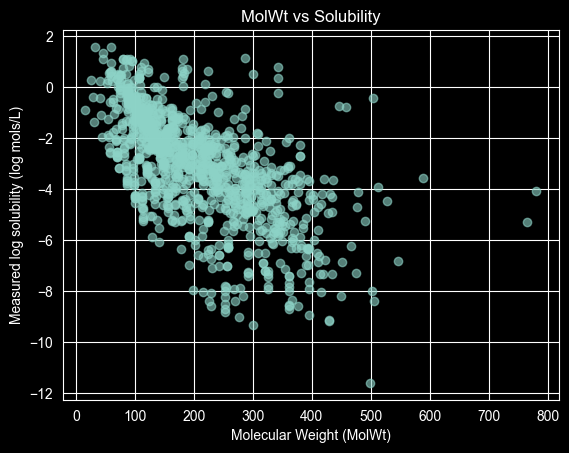

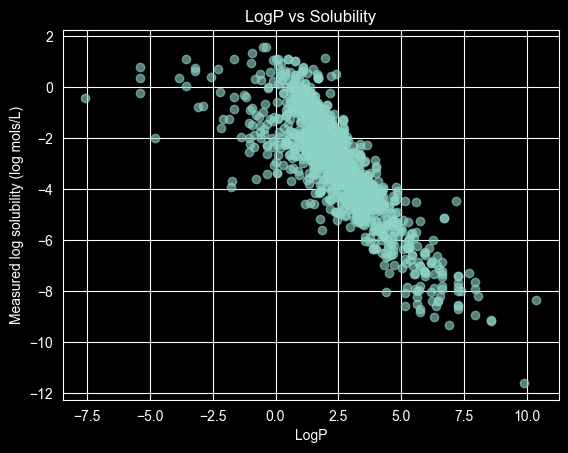

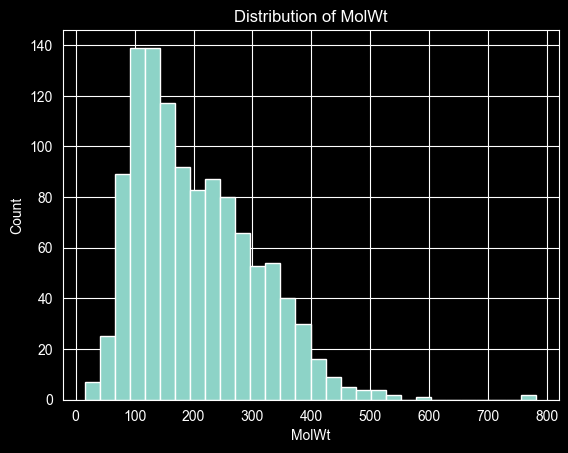

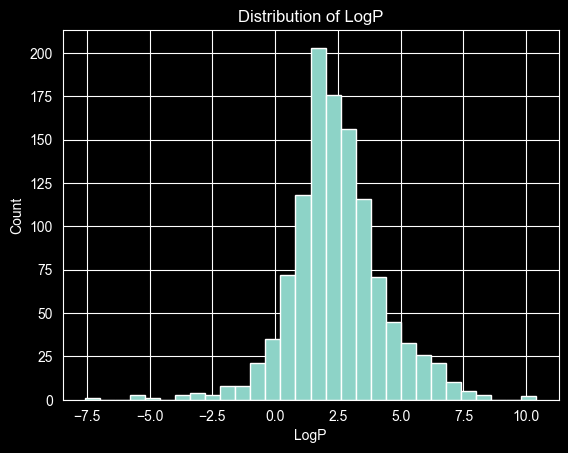

In [4]:
y_col = "measured log(solubility:mol/L)"

plt.figure()
plt.scatter(data["MolWt"], data[y_col], alpha=0.6)
plt.xlabel("Molecular Weight (MolWt)")
plt.ylabel("Measured log solubility (log mols/L)")
plt.title("MolWt vs Solubility")
plt.show()

plt.figure()
plt.scatter(data["LogP"], data[y_col], alpha=0.6)
plt.xlabel("LogP")
plt.ylabel("Measured log solubility (log mols/L)")
plt.title("LogP vs Solubility")
plt.show()

plt.figure()
plt.hist(data["MolWt"], bins=30)
plt.xlabel("MolWt")
plt.ylabel("Count")
plt.title("Distribution of MolWt")
plt.show()

plt.figure()
plt.hist(data["LogP"], bins=30)
plt.xlabel("LogP")
plt.ylabel("Count")
plt.title("Distribution of LogP")
plt.show()


In [5]:
X = data[["MolWt", "LogP"]]
y = data[y_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestRegressor(
    random_state=42,
    n_estimators=100,
    n_jobs=-1
)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))

R2 Score: 0.8644678998844146
MAE: 0.5328117133228251


## AI in Drug Discovery

AI is transforming drug discovery by dramatically accelerating the identification and optimization of promising drug candidates. Machine learning models can analyze vast chemical datasets to predict critical molecular properties, such as solubility, like this notebook, that traditionally requires expensive and time consuming lab experiments. Using tools like RDKit, AI pipelines can automatically extract meaningful molecular descriptors (such as molecular weight and lipophilicity) from chemical structures, turning raw SMILES notation into actionable numerical features. Regression models like Random Forests can then be trained on these features to predict properties with high accuracy, as seen with an R2 score of ~0.86. This enables researchers to virtually screen enormous libraries of compounds and filter out poor candidates before synthesis, saving both cost and time. Beyond solubility, similar approaches are applied to predict toxicity, binding affinity, and pharmacokinetics, covering many of the key hurdles in getting a drug to market. ultimately, AI doesn't replace scientists but empowers them to focus experimental resources on the most promising molecules.